In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
import os
import yaml
import zuko
from helpers.data_transforms import preprocess_data, inverse_preprocess_data, load_in_data

from helpers.models.DNN import count_parameters
from helpers.evaluation import get_kl_dist, discriminate_data_from_samples, get_wasserstein_dist, get_delta_R_neighbors_numba_exact, get_delta_R_neighbors_kdtree

plt.style.use("../science.mplstyle")

In [2]:
from helpers.plotting import plot_hists_1d, plot_corner_hist_2d

In [3]:
BIN_BOUND = 5
NUM_BINS = 60
NUM_FEATURES = 5
NUM_BDTS = 10


ZUKO_ID = "NCSF"
NAME = "OTBC_S_2048"
BATCH_SIZE = 512
NUM_COND_INPUTS = 0
COLLECTION_NAME = "OuterTrackerBarrelCollection"
SEED = 8

EVALUATE_SAMPLES = False

FEATURES = "rphi"
working_dir = "/pscratch/sd/r/rmastand/muon_collider"
log_vars = [1]

In [4]:
save_dir = f"{working_dir}/zuko_outputs/{ZUKO_ID}/{NAME}"



In [5]:
data, _, feature_labels = load_in_data([COLLECTION_NAME], FEATURES, working_dir, 0.5)
flow_samples = np.load(f"{save_dir}/flow_samples.npy")

if FEATURES == "rphi":
    r = np.sqrt(flow_samples[:, 1]**2 + flow_samples[:, 2]**2)
    theta = np.arctan2(flow_samples[:, 2], flow_samples[:, 1])
    flow_samples[:,1] = r
    flow_samples[:,2] = theta

bins_dict = {}
bins_dict_preproc = {i:np.linspace(-BIN_BOUND, BIN_BOUND, NUM_BINS) for i in range(data.shape[1])}

for i in range(data.shape[1]):
    if i in log_vars:
        bins_dict[i] = np.logspace(np.log10(0.9*np.min(data[:,i])), np.log10(1.1*np.max(data[:,i])), NUM_BINS) 
    else:
        bins_dict[i] = np.linspace(np.min(data[:,i] - 3), np.max(data[:,i] + 3), NUM_BINS) 

Feature 4 KL div: 0.011825267034990816 (for gaussian: 0.00047086556169428917)



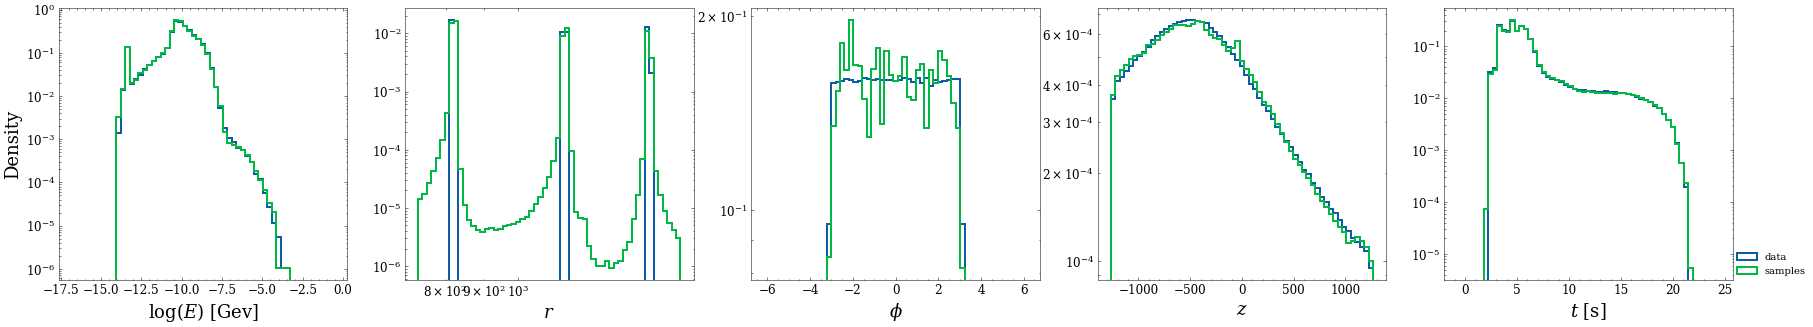

In [6]:

plot_hists_1d({"data":data, "samples": flow_samples}, bins_dict, log_dims=log_vars, labels=feature_labels)


try:
    with open(f"{save_dir}/results.txt") as ifile:
        a = ifile.readlines()[-1]
        print(a)
except:
    pass

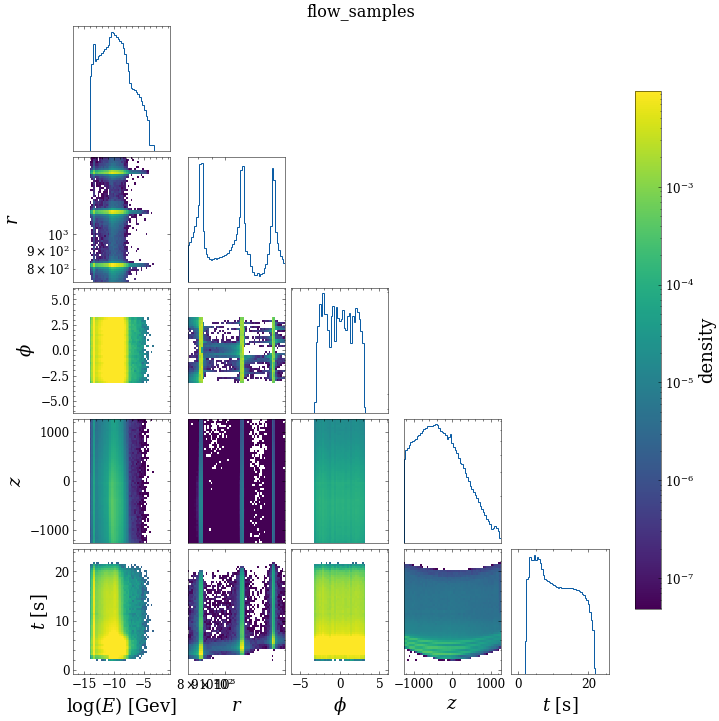

In [7]:
fig_samp, axes_samp = plot_corner_hist_2d(
   flow_samples,
    feature_labels=feature_labels,
    bins_dict=bins_dict,
    log_dims=log_vars,
    title= "flow_samples",
)



# Restrict layers

In [8]:
import pickle
# https://github.com/key4hep/k4geo/blob/main/MuColl/MAIA/compact/MAIA_v0/OuterTracker_o2_v06_01.xml
with open("mask_definitions.pkl", "rb") as ifile:
    mask_definitions = pickle.load(ifile)



def make_mask(r):

    with open("mask_definitions.pkl", "rb") as ifile:
        mask_definitions = pickle.load(ifile)

    mask = []
    for radius in mask_definitions[COLLECTION_NAME].keys():
        for i in range(len(mask_definitions[COLLECTION_NAME][radius]["lower_bounds"])):
           
    
            tmp = (
                (r >= mask_definitions[COLLECTION_NAME][radius]["lower_bounds"][i]) &
                (r <= mask_definitions[COLLECTION_NAME][radius]["upper_bounds"][i])
            )
    
            mask.append(tmp.reshape(-1,1))

    mask = np.any(np.hstack(mask), axis=1)

    return mask


for col_name in mask_definitions.keys():
    print(col_name)
    for r in mask_definitions[col_name].keys():
        print("r:", r)
        print("   lower bounds:", mask_definitions[col_name][r]["lower_bounds"])
        print("   upper bounds:", mask_definitions[col_name][r]["upper_bounds"])
    print()

OuterTrackerBarrelCollection
r: 819
   lower bounds: [817.0680680680681, 819.8508508508509, 819.950950950951, 822.5735735735735]
   upper bounds: [817.3483483483484, 819.910910910911, 820.031031031031, 822.8538538538538]
r: 1153
   lower bounds: [1151.068068068068, 1153.930930930931, 1155.5725725725727, 1156.5735735735736]
   upper bounds: [1151.3083083083084, 1153.990990990991, 1155.6126126126126, 1156.8138138138138]
r: 1486
   lower bounds: [1487.7717717717717, 1490.6146146146145, 1493.2772772772773]
   upper bounds: [1487.9919919919919, 1490.6946946946946, 1493.4774774774776]

InnerTrackerBarrelCollection
r: 127
   lower bounds: [122.42542542542543, 126.62962962962963, 126.88988988988989, 128.25125125125126, 128.3113113113113, 128.43143143143143, 128.51151151151151, 128.5915915915916, 128.7117117117117, 128.77177177177177, 128.85185185185185, 129.07207207207207, 129.3923923923924]
   upper bounds: [122.46546546546547, 126.66966966966967, 127.91091091091091, 128.2912912912913, 128.35

Num. data samples: 3393750
Num. flow samples: 3393750 
Num. flow samples pass mask: 569563 
% flow samples pass mask: 0.1678270349907919


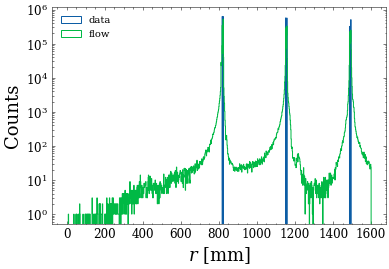

In [9]:
if FEATURES == "rphi":
    r_data = data[:,1]
    r_flow = flow_samples[:,1]
else: 
    r_data = np.sqrt(data[:,1]**2+data[:,2]**2)
    r_flow = np.sqrt(flow_samples[:,1]**2+flow_samples[:,2]**2)

mask_flow = make_mask(r_flow)

print("Num. data samples:", len(r_data))
print("Num. flow samples:",len(mask_flow), "\nNum. flow samples pass mask:", sum(mask_flow), "\n% flow samples pass mask:", sum(mask_flow)/len(mask_flow))


plt.figure()
plt.hist(r_data, bins = np.linspace(0, 1600, 1000), histtype = "step", label = "data")
plt.hist(r_flow, bins = np.linspace(0, 1600, 1000), histtype = "step", label = "flow")
plt.legend()
plt.yscale("log")
plt.xlabel("$r$ [mm]")
plt.ylabel("Counts")
plt.show()

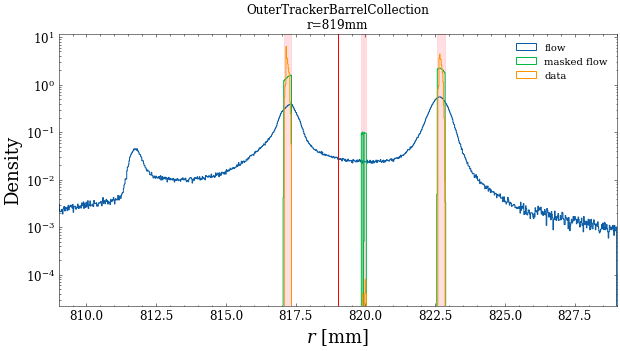

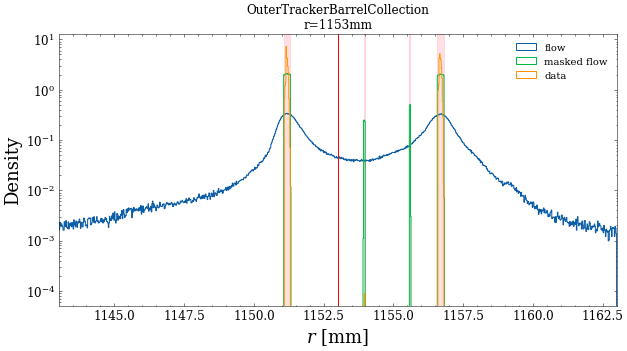

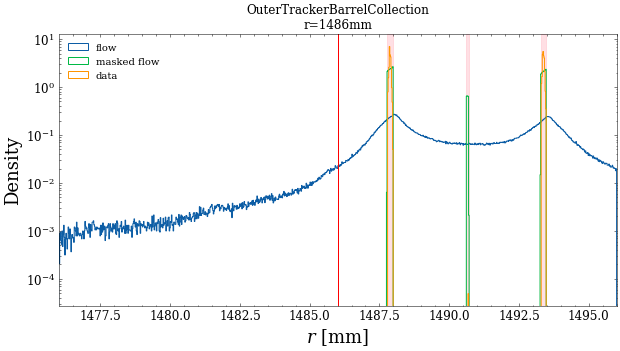

In [10]:

for radius in mask_definitions[COLLECTION_NAME].keys():

    bins = np.linspace(radius - 10, radius + 10, 1000)
   

    plt.figure(figsize = (10, 5))
    for j in range(len(mask_definitions[COLLECTION_NAME][radius]["lower_bounds"])):
        plt.axvspan(mask_definitions[COLLECTION_NAME][radius]["lower_bounds"][j], mask_definitions[COLLECTION_NAME][radius]["upper_bounds"][j], alpha = 0.5, color = "pink")
        
    plt.hist(r_flow, bins = bins, histtype = "step", label = "flow", density = True)
    plt.hist(r_flow[mask_flow], bins = bins, histtype = "step", label = "masked flow", density = True)
    plt.hist(r_data, bins = bins, histtype = "step", label = "data", density = True)
    plt.xlim([radius - 10, radius + 10])
    plt.axvline(radius, color = "r")
    plt.legend()

    plt.title(f"{COLLECTION_NAME}\nr={radius}mm")
    plt.yscale("log")
    plt.xlabel("$r$ [mm]")
    plt.ylabel("Density")
    plt.show()

(<Figure size 2160x360 with 5 Axes>,
 array([<Axes: xlabel='log($E$) [Gev]', ylabel='Density'>,
        <Axes: xlabel='$r$'>, <Axes: xlabel='$\\phi$'>,
        <Axes: xlabel='$z$'>, <Axes: xlabel='$t$ [s]'>], dtype=object))

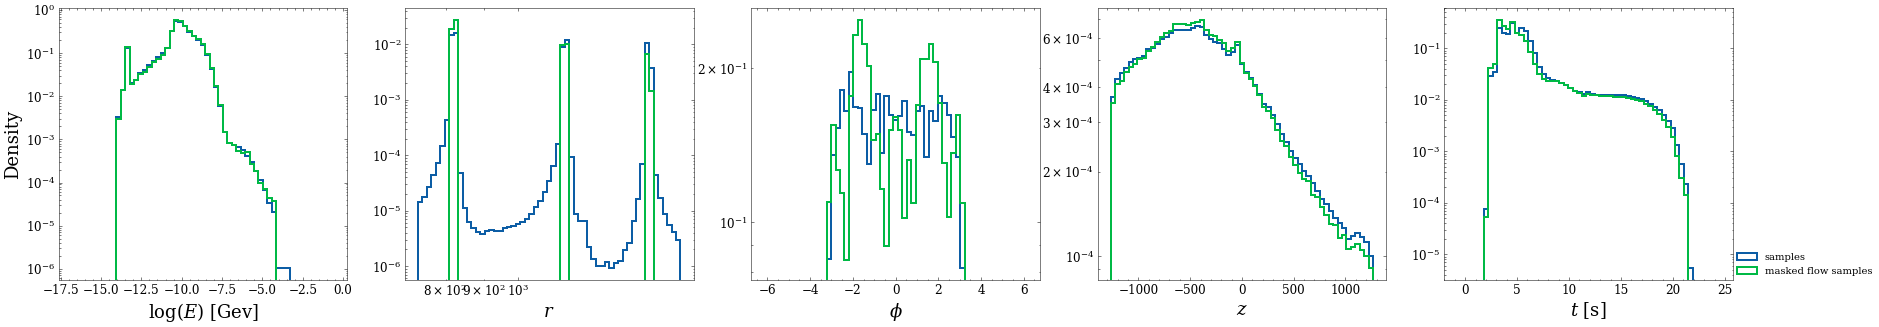

In [11]:

plot_hists_1d({"samples":flow_samples, "masked flow samples":flow_samples[mask_flow]}, bins_dict, log_dims=log_vars, labels=feature_labels)

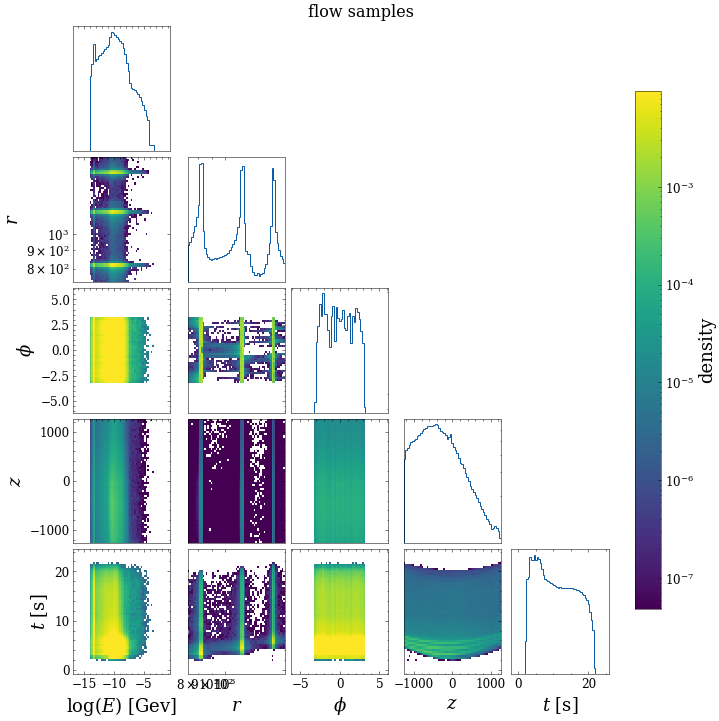

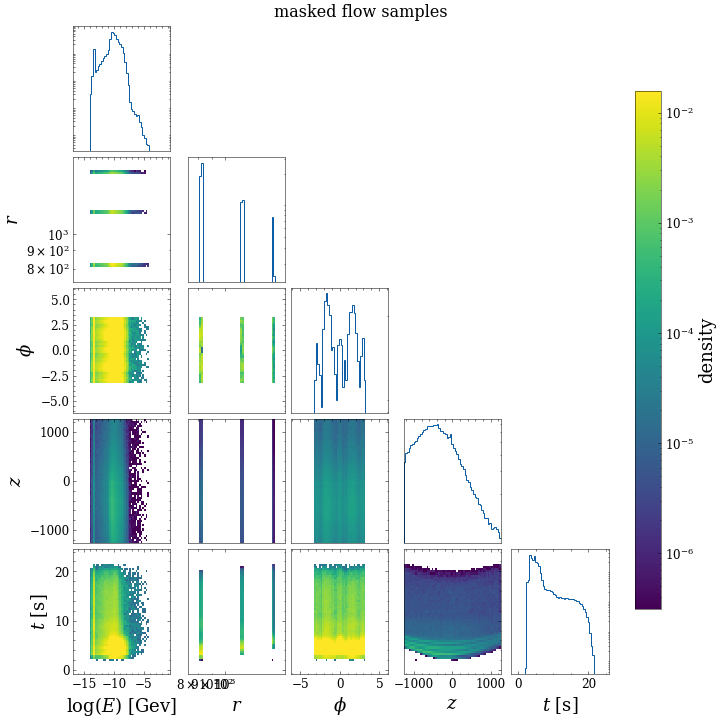

In [12]:


fig_samp, axes_samp = plot_corner_hist_2d(
        flow_samples,
        feature_labels=feature_labels,
        bins_dict=bins_dict,
        log_dims=log_vars,
        title= "flow samples",
    )



fig_samp, axes_samp = plot_corner_hist_2d(
        flow_samples[mask_flow],
        feature_labels=feature_labels,
        bins_dict=bins_dict,
        log_dims=log_vars,
        title= "masked flow samples",
    )

In [13]:
import torch

device = torch.device( "cuda" if torch.cuda.is_available() else "cpu")
print( "Using device: " + str( device ), flush=True)

def run_eval_suite(data, samples, R_values):

    print(f"Len data: {len(data)}, len samples: {len(samples)}")


    # Wasserstein dist
    # wass_dists_samples = get_wasserstein_dist(data, samples)
    # wass_dists_gaussians = get_wasserstein_dist(np.random.normal(size = data.shape), np.random.normal(size = samples.shape))                                            
    # for i, wass_dist in enumerate(wass_dists_samples):
    #     print("Feature {i} Wasserstein distance: {wass_dist} (for gaussian: {wass_dist_gauss})".format(i=i, wass_dist=wass_dist, wass_dist_gauss=wass_dists_gaussians[i]))

    # BDT
    auc_mean, auc_std, best_epoch_list, max_epochs, bdt_list, samples_test, loc_scores = discriminate_data_from_samples(
                                            data,
                                            samples,
                                            3,
                                            "configs/bdt.yml",
                                            model_type="bdt",
                                            plot_losses=True,
                                            device="cuda",
                                            val_size = 0.25, 
                                        )

    print(f"auc {auc_mean} \pm {auc_std}. best epoch {best_epoch_list} of {max_epochs}.\n")

    
    plt.figure()
    plt.hist(loc_scores, bins = np.linspace(0, 1, 100), histtype = "step", density = True)
    plt.yscale("log")
    plt.xlabel("scores")
    plt.ylabel("Density")
    plt.show()
    
    
    X_plot = {"samples":  samples_test}
    percentiles = [90, 95, 99, 99.9]
    for p in percentiles:
        X_plot[f"samples, top {p}%"] =  samples_test[loc_scores >= np.percentile(loc_scores, p)]

    plot_hists_1d({"data":data, **X_plot}, bins_dict, log_dims=log_vars, labels=feature_labels)

    # Clustering
    for R in R_values:
        neighbor_counts_data = get_delta_R_neighbors_numba_exact(data, R, FEATURES)
        neighbor_counts_flow = get_delta_R_neighbors_numba_exact(samples, R, FEATURES)
    
        max_val0 = np.max(neighbor_counts_data)
        max_val1 = np.max(neighbor_counts_flow)
        max_val = np.max([max_val0, max_val1])
    
        bin_spacing = int(max_val/NUM_BINS)
        plt.figure()
        plt.hist(neighbor_counts_data, bins=np.arange(0, max_val, bin_spacing), histtype = "step", label = "data")
        plt.hist(neighbor_counts_flow, bins=np.arange(0, max_val, bin_spacing), histtype = "step", label = "flow")
        plt.legend()
        plt.xlabel(f"# neighbors within $\Delta$R $\leq$ {R}")
        plt.ylabel("Count")
        plt.show()


           


Using device: cuda


Len data: 50000, len samples: 50000
On BDT run 1 of 3...


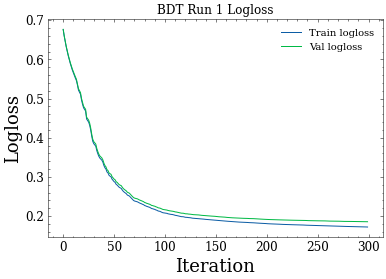

On BDT run 2 of 3...


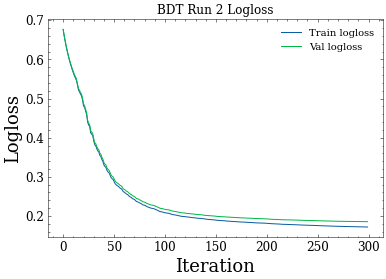

On BDT run 3 of 3...


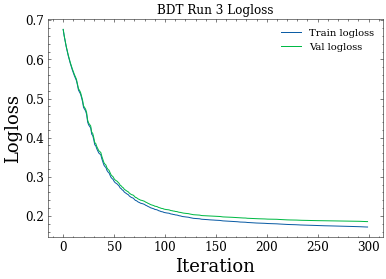

auc 0.9666354261333333 \pm 5.5992461653866436e-05. best epoch [299, 299, 299] of 300.



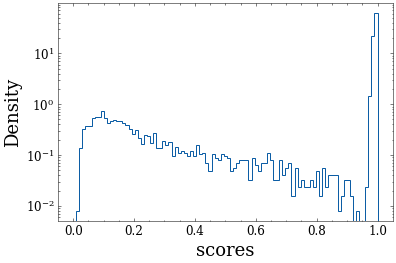

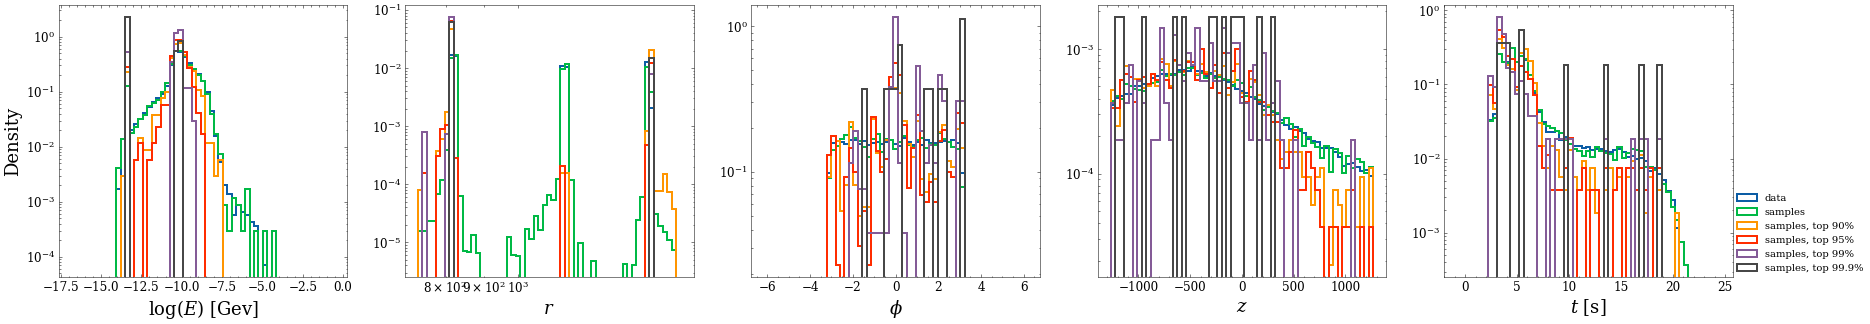

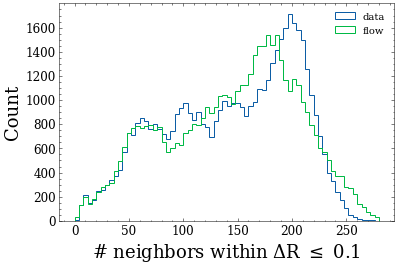

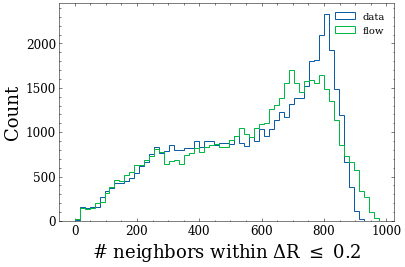

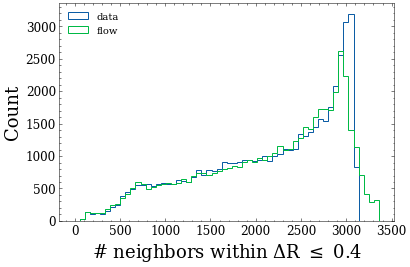

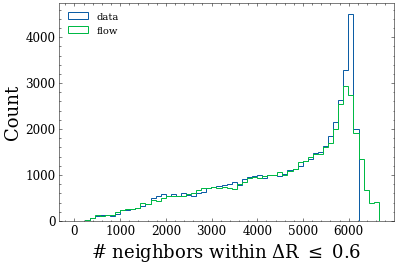

In [14]:
N = 50_000

indices = np.random.choice(data.shape[0], size=N, replace=False)
indices_mask = np.random.choice(sum(mask_flow), size=N, replace=False)



run_eval_suite(data[indices], flow_samples[indices], [0.1, 0.2, 0.4, 0.6])

In [ ]:



run_eval_suite(data[indices], flow_samples[mask_flow][indices_mask], [0.1, 0.2, 0.4, 0.6])

Len data: 50000, len samples: 50000
On BDT run 1 of 3...
